# Lab 10: MCMC Diagnostics, Gibbs Sampling, MH vs Slice Sampling

## Objective
This lab explores how different MCMC algorithms behave under:
- parameter correlation
- non-linear geometry
- poor conditioning

We focus on:
1. Gibbs Sampling (Standard vs Blocked)
2. MCMC Diagnostics (Trace, ACF, R-hat)
3. Metropolis-Hastings vs Slice Sampling

The emphasis is NOT just implementation, but understanding:
> how geometry of distributions affects sampling efficiency

## Why do we need MCMC here?

The posterior:

P(β, σ² | y)

is not directly sampleable because:
- It is high-dimensional
- It has dependencies between parameters

Instead:
We construct a Markov chain whose stationary distribution is the posterior.

Key idea:
> We simulate dependence to eventually approximate independence.

## Problem 18: Bayesian Linear Regression via Gibbs Sampling

We consider the model:

y = β₀ + β₁x₁ + β₂x₂ + ε,   ε ~ N(0, σ²)

Goal:
To sample from the posterior:

P(β₀, β₁, β₂, σ² | y)

Challenge:
- x₁ and x₂ are highly correlated
- This induces correlation in β₁ and β₂
- Standard sampling methods struggle in such settings

We will compare:
1. Standard Gibbs (scalar updates)
2. Blocked Gibbs (vector updates)

## Data Generation


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# generate correlated features
n = 200
x1 = np.random.normal(0, 1, n)
x2 = x1 + np.random.normal(0, 0.1, n)  # high correlation

X = np.column_stack((np.ones(n), x1, x2))

true_beta = np.array([1.0, 2.0, -1.0])
sigma_true = 1.0

y = X @ true_beta + np.random.normal(0, sigma_true, n)

## Gibbs Sampling: Idea and Justification

We exploit conditional distributions:

P(β₁ | β₂, β₃, σ², y), etc.

Algorithm:
- Fix all variables except one
- Sample that variable
- Repeat cyclically

Why does this work?

Because:
If each conditional is correct,
then the joint distribution is preserved as the stationary distribution.

Geometric intuition:
- We explore the space using axis-aligned moves
- Works well when variables are weakly correlated

## Standard Gibbs Implementation


In [2]:
def standard_gibbs(X, y, n_iter=10000):
    n, p = X.shape
    beta = np.zeros(p)
    sigma2 = 1.0

    samples = []

    for _ in range(n_iter):
        for j in range(p):
            X_j = X[:, j]
            residual = y - X @ beta + beta[j]*X_j
            var = sigma2 / np.sum(X_j**2)
            mean = np.sum(X_j * residual) / np.sum(X_j**2)
            beta[j] = np.random.normal(mean, np.sqrt(var))

        res = y - X @ beta
        sigma2 = 1 / np.random.gamma(n/2, 2/np.dot(res, res))

        samples.append(beta.copy())

    return np.array(samples)

## Conditional Distributions

1. $ β | σ², y $
$$
β ∼ N( (XᵀX)⁻¹ Xᵀy , σ² (XᵀX)⁻¹ )
$$
2. $ σ² | β, y $
$$
σ² ∼ Inv-Gamma(n/2, (1/2)(y - Xβ)ᵀ(y - Xβ))
$$
Interpretation:
- $β$ update = linear regression with noise scaling
- $σ²$ update = residual energy

## Blocked Gibbs Sampling

Idea:
Group correlated parameters and sample jointly.

Instead of:
β₁ → β₂

We sample:
(β₀, β₁, β₂) together

Mathematically:

β | σ² ~ N( (XᵀX)⁻¹ Xᵀy , σ² (XᵀX)⁻¹ )

Why better?

Because:
- captures correlation structure
- moves along principal directions of distribution

## Blocked Gibbs Implementation


In [3]:
def blocked_gibbs(X, y, n_iter=10000):
    n, p = X.shape
    beta = np.zeros(p)
    sigma2 = 1.0

    XtX_inv = np.linalg.inv(X.T @ X)

    samples = []

    for _ in range(n_iter):
        mean = XtX_inv @ X.T @ y
        cov = sigma2 * XtX_inv
        beta = np.random.multivariate_normal(mean, cov)

        res = y - X @ beta
        sigma2 = 1 / np.random.gamma(n/2, 2/np.dot(res, res))

        samples.append(beta.copy())

    return np.array(samples)

## Diagnostics: Trace Plots

We plot parameter values vs iteration.

Good trace:
- looks like noise
- no visible trend

Bad trace:
- slow drift
- sticking behavior

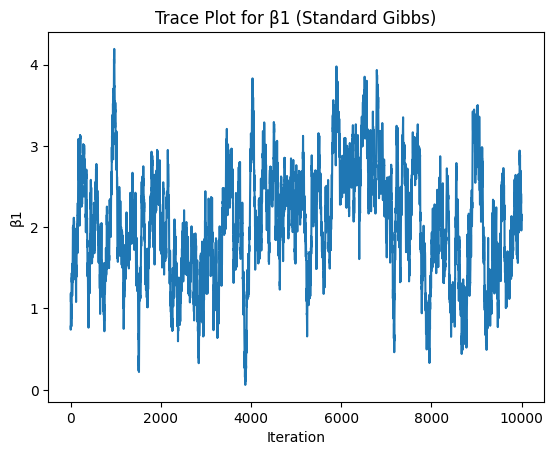

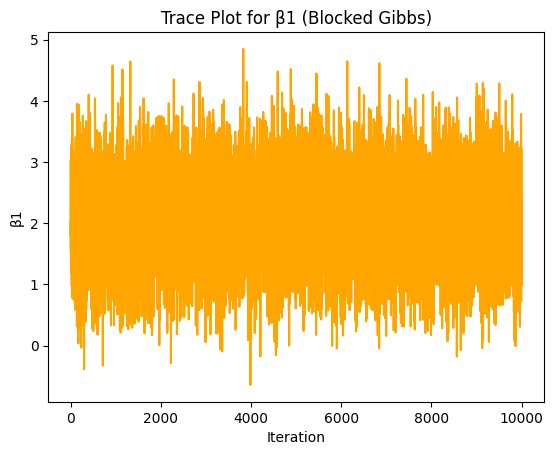

In [16]:
plt.figure()
plt.plot(samples_std[:, 1])
plt.title("Trace Plot for β1 (Standard Gibbs)")
plt.xlabel("Iteration")
plt.ylabel("β1")
plt.show()

plt.figure()
plt.plot(samples_blk[:, 1], color="orange")
plt.title("Trace Plot for β1 (Blocked Gibbs)")
plt.xlabel("Iteration")
plt.ylabel("β1")
plt.show()



## Autocorrelation Function (ACF)

$$
ρ(k) = Corr(x_t, x_{t+k})
$$
Why important?

High autocorrelation:
- redundant samples
- low efficiency

Goal:
- fast decay to zero

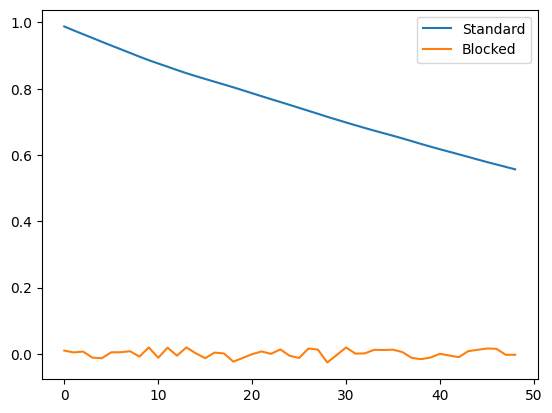

In [5]:
def acf(x, lag=50):
    n = len(x)
    mean = np.mean(x)
    var = np.var(x)

    return [np.correlate(x[:-k]-mean, x[k:]-mean)[0]/((n-k)*var) for k in range(1, lag)]

plt.plot(acf(samples_std[:,1]), label="Standard")
plt.plot(acf(samples_blk[:,1]), label="Blocked")
plt.legend()
plt.show()

## Convergence Diagnostics (Gelman–Rubin, R̂)

- **Idea:**  
  Run multiple chains from different initial values and compare their behavior.

- **Interpretation:**  
  - $ \hat{R} \approx 1 $ → chains agree → convergence achieved  
  - $ \hat{R} > 1.1 $ → chains differ → not converged

- **Observed Behaviour:**  
  Blocked Gibbs typically reaches $ \hat{R} < 1.1 $ faster.  
  Standard Gibbs may take longer due to slow mixing.

- **Reason:**  
  Better mixing (Blocked Gibbs) → chains explore same distribution quickly.

- **Conclusion:**  
  Convergence is reliable when all parameters have $ \hat{R} < 1.1 $;  
  Blocked Gibbs achieves this more efficiently.

In [9]:
def run_chains(gibbs_func, X, y, n_chains=3, n_iter=10000, burn=1000):
    chains = []

    for i in range(n_chains):
        # different initialization each time
        beta_init = np.random.normal(0, 5, X.shape[1])
        sigma2_init = np.random.gamma(2, 2)

        samples = gibbs_func(X, y, n_iter)

        # discard burn-in
        samples = samples[burn:]
        chains.append(samples)

    return chains

def compute_rhat_all(chains):
    chains = np.array(chains)   # shape: (m, n, p)
    m, n, p = chains.shape

    rhat_vals = []

    for j in range(p):
        param_chains = chains[:,:,j]

        chain_means = np.mean(param_chains, axis=1)
        chain_vars  = np.var(param_chains, axis=1, ddof=1)

        B = n * np.var(chain_means, ddof=1)
        W = np.mean(chain_vars)

        var_hat = ((n - 1)/n)*W + (1/n)*B
        R_hat = np.sqrt(var_hat / W)

        rhat_vals.append(R_hat)

    return rhat_vals

chains_std = run_chains(standard_gibbs, X, y)
chains_blk = run_chains(blocked_gibbs, X, y)

rhat_std = compute_rhat_all(chains_std)
rhat_blk = compute_rhat_all(chains_blk)

print("R̂ Standard Gibbs:", rhat_std)
print("R̂ Blocked Gibbs:", rhat_blk)

R̂ Standard Gibbs: [np.float64(0.9999991909844971), np.float64(1.001423751023836), np.float64(1.001450158674952)]
R̂ Blocked Gibbs: [np.float64(0.9999512983548603), np.float64(1.000015829800329), np.float64(1.000023737135321)]


## Problem 19: Sampling from a "Bad" Distribution

We consider the Rosenbrock (banana) density:

f(x₁, x₂) ∝ exp( -(1-x₁)² - 100(x₂ - x₁²)² )

Properties:
- curved ridge
- strong nonlinear dependence

Goal:
Compare:
1. Metropolis-Hastings (MH)
2. Slice Sampling

Focus:
How geometry affects sampling performance

## Why is this distribution hard?

The high-density region:
- is narrow
- curves nonlinearly

Algorithms assuming isotropic movement fail.

This tests:
> adaptability of sampling methods

## Metropolis-Hastings

Proposal:
x* = x + ε,   ε ~ N(0, σ²I)

Acceptance:
r = f(x*) / f(x)

Problem:
σ is fixed

Tradeoff:
- small σ → slow exploration
- large σ → rejection

In [17]:
def banana_density(x):
    return np.exp(-(1-x[0])**2 - 100*(x[1]-x[0]**2)**2)

def mh_sampler(n_iter=10000, sigma=0.5):
    x = np.array([0.0, 0.0])
    samples = []

    for _ in range(n_iter):
        x_prop = x + np.random.normal(0, sigma, 2)
        r = banana_density(x_prop) / banana_density(x)

        if np.random.rand() < r:
            x = x_prop

        samples.append(x.copy())

    return np.array(samples)

## Slice Sampling

Instead of proposing blindly:

1. Sample height y ~ Uniform(0, f(x))
2. Find interval where f(x) > y
3. Sample within that region

Key advantage:
- adapts to local structure
- no step-size tuning

In [33]:
def slice_sampler(n_iter=10000, w=2.0):
    x = np.array([0.0, 0.0])
    samples = []

    for _ in range(n_iter):
        for d in range(2):
            y = np.random.uniform(0, banana_density(x))

            # stepping out
            L = x[d] - w * np.random.rand()
            R = L + w

            def f(val):
                temp = x.copy()
                temp[d] = val
                return banana_density(temp)

            while f(L) > y:
                L -= w
            while f(R) > y:
                R += w

            # shrinkage
            while True:
                x_prop = np.random.uniform(L, R)
                if f(x_prop) > y:
                    x[d] = x_prop
                    break
                elif x_prop < x[d]:
                    L = x_prop
                else:
                    R = x_prop

        samples.append(x.copy())

    return np.array(samples)

## Scatter Plot (samples over contours)

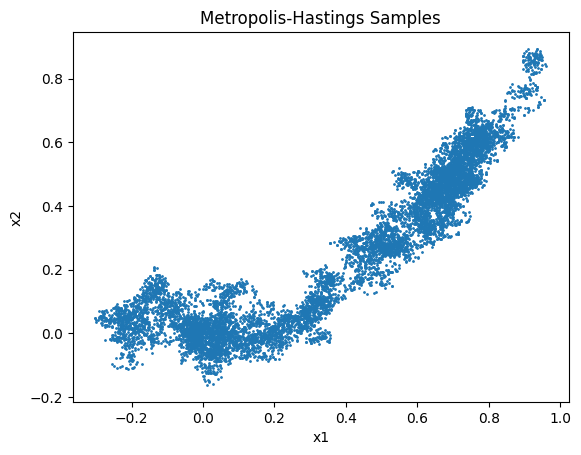

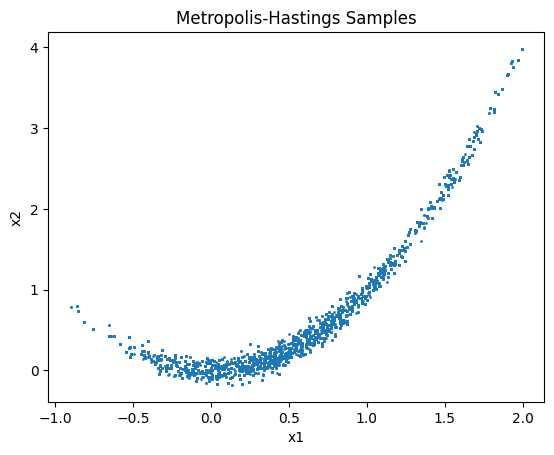

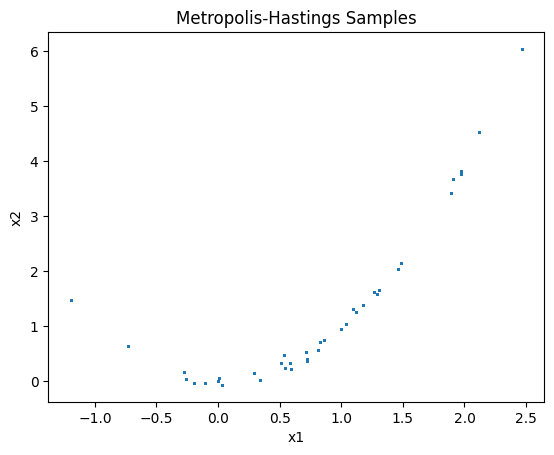

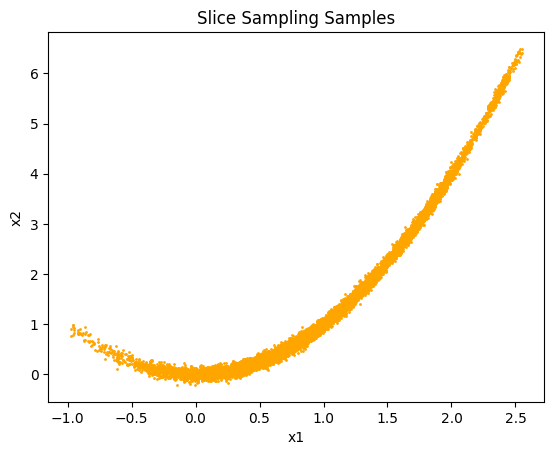

In [44]:
mh_samples = mh_sampler(n_iter=10000, sigma=0.01)
plt.figure()
plt.scatter(mh_samples[:, 0], mh_samples[:, 1], s=1)
plt.title("Metropolis-Hastings Samples")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

mh_samples = mh_sampler(n_iter=10000, sigma=0.5)
plt.figure()
plt.scatter(mh_samples[:, 0], mh_samples[:, 1], s=1)
plt.title("Metropolis-Hastings Samples")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

mh_samples = mh_sampler(n_iter=10000, sigma=5)
plt.figure()
plt.scatter(mh_samples[:, 0], mh_samples[:, 1], s=1)
plt.title("Metropolis-Hastings Samples")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

plt.figure()
plt.scatter(slice_samples[:, 0], slice_samples[:, 1], s=1, color="orange")
plt.title("Slice Sampling Samples")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

### Scatter Plot Observation

- MH samples are concentrated and struggle to follow the curved ridge.
- Slice sampling fills the entire banana shape, including the arms.

**Conclusion:** Slice sampling explores the geometry better.

## ACF for $x_{2}$

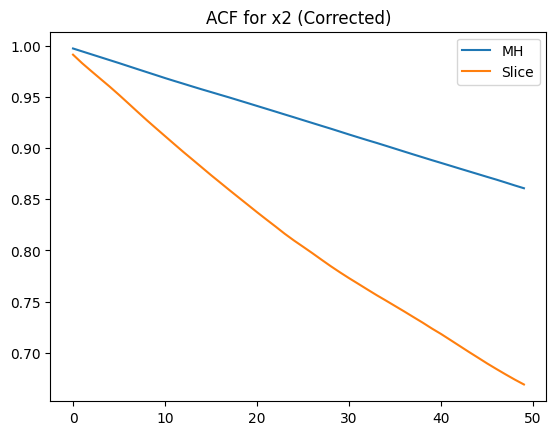

In [39]:
def acf(x, max_lag=50):
    x = np.asarray(x)
    x = x - np.mean(x)
    n = len(x)

    autocorr = np.correlate(x, x, mode='full')
    autocorr = autocorr[n-1:] / autocorr[n-1]  # normalize

    return autocorr[1:max_lag+1]

mh_samples = mh_sampler(n_iter=10000, sigma=1.5)
slice_samples = slice_sampler(n_iter=10000, w=2.0)

plt.plot(acf(mh_samples[:,1]), label="MH")
plt.plot(acf(slice_samples[:,1]), label="Slice")

plt.legend()
plt.title("ACF for x2 (Corrected)")
plt.show()

## Trace Plot

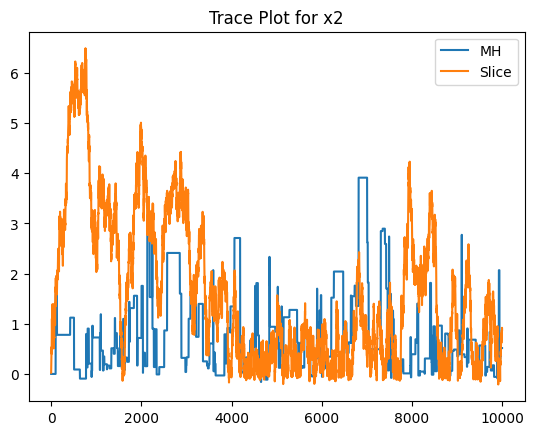

In [41]:
mh_samples = mh_sampler(n_iter=10000, sigma=1.5)
slice_samples = slice_sampler(n_iter=10000, w=2.0)

plt.plot(mh_samples[:,1], label="MH")
plt.plot(slice_samples[:,1], label="Slice")

plt.legend()
plt.title("Trace Plot for x2")
plt.show()

### Trace Plot Observation

- MH stays in one region for long periods → poor mixing.
- Slice sampling moves freely across regions → good mixing.

**Conclusion:** MH struggles to traverse the curved density.

## Why fixed proposal width hurts MH?

MH uses a fixed step size (σ):

- In high curvature regions → needs small steps → large steps get rejected
- In flat regions → needs large steps → small steps are too slow

Since σ is fixed:
- it cannot adapt to local geometry
- leads to either rejection or slow exploration

In the banana distribution:
- curvature changes across space
- MH cannot "turn" along the ridge efficiently

**Conclusion:**
Fixed proposal makes MH inefficient in distributions with varying curvature, while Slice sampling adapts automatically.

## Key Takeaways

1. Geometry dictates performance
2. Correlation slows down naive samplers
3. Blocked Gibbs improves mixing
4. MH suffers from fixed step size
5. Slice sampling adapts automatically

Most important idea:
> MCMC is not just about algorithms — it is about matching the algorithm to the geometry of the distribution